# PhoBERT Baseline Model for Student Feedback Sentiment Analysis

## Mục tiêu
- Xây dựng mô hình PhoBERT để phân loại cảm xúc từ phản hồi sinh viên
- Đánh giá hiệu suất với các metric: Accuracy, F1-Score, Precision, Recall
- Trực quan hóa kết quả với các biểu đồ

## Label Mapping
- **0**: Tiêu cực (Negative)
- **1**: Trung lập (Neutral)  
- **2**: Tích cực (Positive)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 1. Import Libraries & Setup

In [ ]:
# Import các thư viện cần thiết
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
import random
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

# Sklearn metrics & utils
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils import resample, compute_class_weight

# Tqdm for progress bar
from tqdm.auto import tqdm

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

## 2. Load Data

In [ ]:
# Định nghĩa đường dẫn dữ liệu
DATA_DIR = '/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/data/processed'

def load_data(split):
    """Load data từ các file txt"""
    base_path = os.path.join(DATA_DIR, split)

    # Đọc sentences
    with open(os.path.join(base_path, 'sents.txt'), 'r', encoding='utf-8') as f:
        sentences = [line.strip() for line in f.readlines()]

    # Đọc sentiments
    with open(os.path.join(base_path, 'sentiments.txt'), 'r', encoding='utf-8') as f:
        sentiments = [int(line.strip()) for line in f.readlines()]

    # Đọc topics
    with open(os.path.join(base_path, 'topics.txt'), 'r', encoding='utf-8') as f:
        topics = [int(line.strip()) for line in f.readlines()]

    return pd.DataFrame({
        'text': sentences,
        'sentiment': sentiments,
        'topic': topics
    })

# Load train, validation, test data
train_df = load_data('train')
val_df = load_data('validation')
test_df = load_data('test')

print(f"Train set: {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")
print(f"Test set: {len(test_df)} samples")
print(f"\nTotal: {len(train_df) + len(val_df) + len(test_df)} samples")

In [ ]:
# Xem mẫu dữ liệu
print("Sample data:")
train_df.head(10)

## 3. Exploratory Data Analysis (EDA)

In [ ]:
# Label mapping
LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
NUM_LABELS = 3

# Tạo thư mục results nếu chưa có (cho Colab)
RESULTS_DIR = '/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Baseline'
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results directory: {RESULTS_DIR}")

# Thống kê phân bố nhãn
def plot_label_distribution():
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    datasets = [('Train', train_df), ('Validation', val_df), ('Test', test_df)]
    colors = ['#ff6b6b', '#feca57', '#48dbfb']  # Red, Yellow, Blue

    for idx, (name, df) in enumerate(datasets):
        counts = df['sentiment'].value_counts().sort_index()
        labels = [LABEL_MAP[i] for i in counts.index]

        bars = axes[idx].bar(labels, counts.values, color=colors, edgecolor='black')
        axes[idx].set_title(f'{name} Set Distribution\n(n={len(df)})', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Sentiment')
        axes[idx].set_ylabel('Count')

        # Thêm số liệu trên cột
        for bar, count in zip(bars, counts.values):
            height = bar.get_height()
            axes[idx].annotate(f'{count}\n({count/len(df)*100:.1f}%)',
                             xy=(bar.get_x() + bar.get_width()/2, height),
                             ha='center', va='bottom', fontsize=10)

    plt.suptitle('Biểu đồ Phân bố Nhãn Cảm xúc (Dataset Distribution)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/label_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_label_distribution()

In [ ]:
# Thống kê chi tiết
print("="*60)
print("THỐNG KÊ CHI TIẾT PHÂN BỐ NHÃN")
print("="*60)

for name, df in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    print(f"\n{name} Set:")
    for label in sorted(df['sentiment'].unique()):
        count = (df['sentiment'] == label).sum()
        pct = count / len(df) * 100
        print(f"  {LABEL_MAP[label]}: {count} ({pct:.2f}%)")

## 4. Prepare Dataset & DataLoader

In [ ]:
# Load PhoBERT tokenizer
MODEL_NAME = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Loaded tokenizer: {MODEL_NAME}")

In [ ]:
# Custom Dataset class
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Hyperparameters
MAX_LENGTH = 128
BATCH_SIZE = 16

# Create datasets
train_dataset = SentimentDataset(
    train_df['text'].values,
    train_df['sentiment'].values,
    tokenizer,
    MAX_LENGTH
)

val_dataset = SentimentDataset(
    val_df['text'].values,
    val_df['sentiment'].values,
    tokenizer,
    MAX_LENGTH
)

test_dataset = SentimentDataset(
    test_df['text'].values,
    test_df['sentiment'].values,
    tokenizer,
    MAX_LENGTH
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

## 5. Load PhoBERT Model

In [ ]:
# Load pre-trained PhoBERT model with classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    output_attentions=False,
    output_hidden_states=False
)

model = model.to(device)
print(f"Model loaded and moved to {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

## 6. Training Setup

In [ ]:
# Training hyperparameters
EPOCHS = 5
LEARNING_RATE = 2e-5
WARMUP_STEPS = 0

# Optimizer
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, eps=1e-8)

# Total training steps
total_steps = len(train_loader) * EPOCHS

# Learning rate scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

print(f"Training Configuration:")
print(f"  - Epochs: {EPOCHS}")
print(f"  - Learning Rate: {LEARNING_RATE}")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Total Steps: {total_steps}")

## 7. Training Functions

In [ ]:
def train_epoch(model, dataloader, optimizer, scheduler, device):
    """Train one epoch"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(dataloader, desc='Training', leave=False)

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, accuracy, f1


def evaluate(model, dataloader, device):
    """Evaluate model"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')

    return avg_loss, accuracy, f1, precision, recall, all_preds, all_labels

## 8. Training Loop

In [ ]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'train_f1': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': [],
    'val_precision': [],
    'val_recall': []
}

best_val_f1 = 0
best_model_state = None

print("="*60)
print("STARTING TRAINING")
print("="*60)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 40)

    # Train
    train_loss, train_acc, train_f1 = train_epoch(
        model, train_loader, optimizer, scheduler, device
    )

    # Validate
    val_loss, val_acc, val_f1, val_precision, val_recall, _, _ = evaluate(
        model, val_loader, device
    )

    # Log metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)

    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val F1:   {val_f1:.4f}")
    print(f"  Val Precision: {val_precision:.4f} | Val Recall: {val_recall:.4f}")

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = model.state_dict().copy()
        print(f"  ✓ New best model saved! (F1: {val_f1:.4f})")

print("\n" + "="*60)
print("TRAINING COMPLETED")
print(f"Best Validation F1: {best_val_f1:.4f}")
print("="*60)

## 9. Save Model

In [ ]:
# Load best model state
model.load_state_dict(best_model_state)

# Save model
MODEL_SAVE_PATH = f'{RESULTS_DIR}/phobert_sentiment_model.pt'
torch.save({
    'model_state_dict': best_model_state,
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'best_val_f1': best_val_f1,
    'label_map': LABEL_MAP,
    'config': {
        'model_name': MODEL_NAME,
        'max_length': MAX_LENGTH,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'learning_rate': LEARNING_RATE
    }
}, MODEL_SAVE_PATH)

print(f"Model saved to: {MODEL_SAVE_PATH}")

## 10. Visualize Training History

In [ ]:
# Biểu đồ Accuracy / F1-Score theo Epoch
def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Loss
    axes[0, 0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], 'r-o', label='Val Loss', linewidth=2)
    axes[0, 0].set_title('Loss theo Epoch', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Accuracy
    axes[0, 1].plot(epochs, history['train_acc'], 'b-o', label='Train Accuracy', linewidth=2)
    axes[0, 1].plot(epochs, history['val_acc'], 'r-o', label='Val Accuracy', linewidth=2)
    axes[0, 1].set_title('Accuracy theo Epoch', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # F1-Score
    axes[1, 0].plot(epochs, history['train_f1'], 'b-o', label='Train F1 (Macro)', linewidth=2)
    axes[1, 0].plot(epochs, history['val_f1'], 'r-o', label='Val F1 (Macro)', linewidth=2)
    axes[1, 0].set_title('F1-Score (Macro) theo Epoch', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1-Score')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Precision & Recall
    axes[1, 1].plot(epochs, history['val_precision'], 'g-o', label='Val Precision', linewidth=2)
    axes[1, 1].plot(epochs, history['val_recall'], 'm-o', label='Val Recall', linewidth=2)
    axes[1, 1].plot(epochs, history['val_f1'], 'r-o', label='Val F1', linewidth=2)
    axes[1, 1].set_title('Precision / Recall / F1 theo Epoch', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle('Biểu đồ Accuracy / F1-Score theo Epoch', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history)

## 11. Evaluate on Test Set (Only Once!)

In [ ]:
# Đánh giá trên Test Set (chỉ chạy 1 lần)
print("="*60)
print("EVALUATING ON TEST SET")
print("="*60)

test_loss, test_acc, test_f1, test_precision, test_recall, test_preds, test_labels = evaluate(
    model, test_loader, device
)

print(f"\nTest Results:")
print(f"  Accuracy:  {test_acc:.4f}")
print(f"  F1 (Macro): {test_f1:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")

## 12. Confusion Matrix

In [ ]:
# Confusion Matrix với chú thích
def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion Matrix (counts)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[0])
    axes[0].set_title('Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    # Confusion Matrix (percentages)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[1])
    axes[1].set_title('Confusion Matrix (Percentage %)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    # Thêm chú thích
    fig.text(0.5, -0.05,
             'Chú thích: Mỗi hàng thể hiện tỷ lệ phân loại của nhãn thật.\n'
             'Đường chéo chính cho thấy tỷ lệ dự đoán đúng.',
             ha='center', fontsize=10, style='italic')

    plt.suptitle('Confusion Matrix - PhoBERT Baseline', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

labels = [LABEL_MAP[i] for i in range(NUM_LABELS)]
plot_confusion_matrix(test_labels, test_preds, labels)

## 13. Precision - Recall - F1 by Class

In [ ]:
# Classification Report
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

report = classification_report(test_labels, test_preds,
                               target_names=labels,
                               digits=4,
                               output_dict=True)

# Display as DataFrame
report_df = pd.DataFrame(report).transpose()
print(report_df.round(4))

In [ ]:
# Bảng Precision – Recall – F1 theo lớp (Visualization)
def plot_metrics_by_class(report, labels):
    metrics = ['precision', 'recall', 'f1-score']

    data = {label: [report[label][m] for m in metrics] for label in labels}

    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))

    colors = ['#3498db', '#e74c3c', '#2ecc71']

    for i, metric in enumerate(metrics):
        values = [report[label][metric] for label in labels]
        bars = ax.bar(x + i*width, values, width, label=metric.capitalize(), color=colors[i])

        # Thêm giá trị trên cột
        for bar, val in zip(bars, values):
            ax.annotate(f'{val:.3f}',
                       xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                       ha='center', va='bottom', fontsize=9)

    ax.set_ylabel('Score')
    ax.set_title('Bảng Precision – Recall – F1 (theo lớp)', fontsize=14, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/metrics_by_class.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_metrics_by_class(report, labels)

## 14. True vs Predicted Label Comparison

In [ ]:
# So sánh nhãn thật vs nhãn dự đoán (tỉ lệ %)
def plot_true_vs_predicted(y_true, y_pred, labels):
    # Đếm phân bố
    true_counts = Counter(y_true)
    pred_counts = Counter(y_pred)

    # Tính tỉ lệ %
    total = len(y_true)
    true_pct = [true_counts[i] / total * 100 for i in range(len(labels))]
    pred_pct = [pred_counts[i] / total * 100 for i in range(len(labels))]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    bars1 = ax.bar(x - width/2, true_pct, width, label='True Labels', color='#3498db', edgecolor='black')
    bars2 = ax.bar(x + width/2, pred_pct, width, label='Predicted Labels', color='#e74c3c', edgecolor='black')

    # Thêm giá trị trên cột
    for bar, pct, count in zip(bars1, true_pct, [true_counts[i] for i in range(len(labels))]):
        ax.annotate(f'{pct:.1f}%\n({count})',
                   xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                   ha='center', va='bottom', fontsize=9)

    for bar, pct, count in zip(bars2, pred_pct, [pred_counts[i] for i in range(len(labels))]):
        ax.annotate(f'{pct:.1f}%\n({count})',
                   xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                   ha='center', va='bottom', fontsize=9)

    ax.set_ylabel('Percentage (%)')
    ax.set_title('So sánh Nhãn Thật vs Nhãn Dự đoán (Tỉ lệ %)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/true_vs_predicted.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_true_vs_predicted(test_labels, test_preds, labels)

## 15. Summary Results

In [ ]:
# Tổng hợp kết quả
print("="*60)
print("TỔNG HỢP KẾT QUẢ - PHOBERT BASELINE")
print("="*60)

summary_data = {
    'Metric': ['Accuracy', 'F1-Score (Macro)', 'Precision (Macro)', 'Recall (Macro)'],
    'Validation': [
        f"{history['val_acc'][-1]:.4f}",
        f"{history['val_f1'][-1]:.4f}",
        f"{history['val_precision'][-1]:.4f}",
        f"{history['val_recall'][-1]:.4f}"
    ],
    'Test': [
        f"{test_acc:.4f}",
        f"{test_f1:.4f}",
        f"{test_precision:.4f}",
        f"{test_recall:.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv(f'{RESULTS_DIR}/phobert_baseline_summary.csv', index=False)
print(f"\nResults saved to: {RESULTS_DIR}/phobert_baseline_summary.csv")

## 16. Limitations & Hybrid Model Recommendations

In [ ]:
# Phân tích hạn chế và đề xuất cho Hybrid Model
print("="*60)
print("NHẬN XÉT HẠN CHẾ & ĐỀ XUẤT CHO HYBRID MODEL")
print("="*60)

# Phân tích kết quả theo lớp
print("\n📊 PHÂN TÍCH KẾT QUẢ THEO LỚP:")
for label in labels:
    precision = report[label]['precision']
    recall = report[label]['recall']
    f1 = report[label]['f1-score']
    support = report[label]['support']

    status = "✓" if f1 >= 0.8 else "⚠" if f1 >= 0.6 else "✗"
    print(f"  {status} {label}: P={precision:.3f}, R={recall:.3f}, F1={f1:.3f} (n={int(support)})")

print("\n" + "-"*60)
print("🔍 HẠN CHẾ CỦA PHOBERT BASELINE:")
print("-"*60)

limitations = """
1. **Imbalanced Classes**:
   - Nếu phân bố nhãn không đều, model có thể bias về class đa số
   - Cần xem xét class weights hoặc oversampling cho minority class

2. **Context Understanding**:
   - PhoBERT hiểu ngữ cảnh tốt nhưng có thể miss các sắc thái tinh tế
   - Các câu mang tính mỉa mai, châm biếm có thể bị phân loại sai

3. **Domain-Specific Vocabulary**:
   - Từ vựng đặc thù trong phản hồi sinh viên (tên giảng viên, môn học)
   - Có thể cần fine-tune thêm trên domain data

4. **Neutral Class Challenge**:
   - Lớp Neutral thường có ranh giới mờ với Positive/Negative
   - Cần xem xét kết hợp với rule-based approach

5. **Short Text Limitation**:
   - Các câu ngắn có ít context để model học
   - Có thể kết hợp với feature engineering

6. **Computational Cost**:
   - PhoBERT yêu cầu tài nguyên tính toán lớn
   - Inference time cao hơn các model truyền thống
"""
print(limitations)

print("-"*60)
print("💡 ĐỀ XUẤT CHO HYBRID MODEL:")
print("-"*60)

recommendations = """
1. **Kết hợp PhoBERT + Lexicon-based**:
   - Sử dụng sentiment lexicon (như VnSentiWordNet) để bổ sung
   - Tạo ensemble: PhoBERT features + Lexicon scores

2. **Multi-task Learning**:
   - Train đồng thời sentiment + topic classification
   - Tận dụng mối quan hệ giữa topic và sentiment

3. **Attention Mechanism Enhancement**:
   - Thêm attention layer để focus vào sentiment-bearing words
   - Kết hợp với aspect-based sentiment analysis

4. **Ensemble Methods**:
   - Kết hợp PhoBERT với SVM/Random Forest trên TF-IDF features
   - Voting hoặc stacking ensemble

5. **Rule-based Post-processing**:
   - Xử lý các trường hợp đặc biệt bằng rules
   - Negation handling, intensifier detection

6. **Data Augmentation**:
   - Back-translation
   - Synonym replacement
   - Random insertion/deletion
"""
print(recommendations)

## 17. Sample Predictions

In [ ]:
# Xem một số mẫu dự đoán
def show_sample_predictions(df, preds, labels_map, n_samples=10):
    """Hiển thị một số mẫu dự đoán"""
    print("="*80)
    print("MẪU DỰ ĐOÁN")
    print("="*80)

    # Lấy ngẫu nhiên
    indices = np.random.choice(len(df), min(n_samples, len(df)), replace=False)

    for i, idx in enumerate(indices, 1):
        text = df.iloc[idx]['text']
        true_label = df.iloc[idx]['sentiment']
        pred_label = preds[idx]

        status = "✓" if true_label == pred_label else "✗"

        print(f"\n[{i}] {status}")
        print(f"    Text: {text[:100]}{'...' if len(text) > 100 else ''}")
        print(f"    True: {labels_map[true_label]} | Pred: {labels_map[pred_label]}")

show_sample_predictions(test_df, test_preds, LABEL_MAP, n_samples=15)

In [ ]:
# Phân tích các trường hợp dự đoán sai
def analyze_misclassifications(df, preds, labels_map):
    """Phân tích các trường hợp dự đoán sai"""
    print("="*80)
    print("PHÂN TÍCH CÁC TRƯỜNG HỢP DỰ ĐOÁN SAI")
    print("="*80)

    misclassified = []
    for idx in range(len(df)):
        true_label = df.iloc[idx]['sentiment']
        pred_label = preds[idx]

        if true_label != pred_label:
            misclassified.append({
                'text': df.iloc[idx]['text'],
                'true': labels_map[true_label],
                'pred': labels_map[pred_label]
            })

    print(f"\nTổng số dự đoán sai: {len(misclassified)} / {len(df)} ({len(misclassified)/len(df)*100:.2f}%)")

    # Phân tích theo loại lỗi
    error_types = Counter([(m['true'], m['pred']) for m in misclassified])
    print("\nPhân bố lỗi theo loại:")
    for (true, pred), count in error_types.most_common():
        print(f"  {true} → {pred}: {count} lỗi")

    # Hiển thị một số ví dụ
    print("\nMột số ví dụ dự đoán sai:")
    for i, m in enumerate(misclassified[:5], 1):
        print(f"\n[{i}] True: {m['true']} | Pred: {m['pred']}")
        print(f"    \"{m['text'][:80]}{'...' if len(m['text']) > 80 else ''}\"")

analyze_misclassifications(test_df, test_preds, LABEL_MAP)

---
## Kết luận

Notebook này đã implement thành công **PhoBERT Baseline Model** cho bài toán **Student Feedback Sentiment Analysis** với các thành phần:

1. ✅ Load và phân tích dữ liệu từ thư mục `processed`
2. ✅ Biểu đồ phân bố nhãn cảm xúc
3. ✅ Fine-tune PhoBERT cho classification (5 epochs)
4. ✅ Biểu đồ Accuracy / F1-Score theo epoch
5. ✅ Confusion Matrix với chú thích
6. ✅ So sánh nhãn thật vs nhãn dự đoán
7. ✅ Bảng Precision – Recall – F1 theo lớp
8. ✅ Save model và logging metrics
9. ✅ Nhận xét hạn chế và đề xuất cho Hybrid Model

**Các biểu đồ đã lưu:**
- `results/label_distribution.png`
- `results/training_history.png`
- `results/confusion_matrix.png`
- `results/metrics_by_class.png`
- `results/true_vs_predicted.png`

**Model đã lưu:**
- `results/phobert_sentiment_model.pt`

---
## 19. IMPLEMENTATION: APPROACH 2 - Best Performance

Triển khai **Focal Loss + Oversampling + Augmentation** để cải thiện Neutral F1-Score từ 57% → 73-78%

### 19.0. Prerequisites Check & Data Loading

In [ ]:
import os
from sklearn.utils import resample, compute_class_weight
print("="*80)
print("PREREQUISITES CHECK & DATA LOADING")
print("="*80)

# =====================================================
# IMPORTANT: Chạy cell này TRƯỚC KHI chạy Section 19
# Cell này sẽ load lại data và model nếu chưa có
# =====================================================

# Check if variables exist, if not, reload them
missing_vars = []

# 1. Check data variables
try:
    _ = train_df
    print("✓ train_df available")
except NameError:
    missing_vars.append('train_df')
    print("✗ train_df not found - will reload")

try:
    _ = val_df
    print("✓ val_df available")
except NameError:
    missing_vars.append('val_df')
    print("✗ val_df not found - will reload")

try:
    _ = test_df
    print("✓ test_df available")
except NameError:
    missing_vars.append('test_df')
    print("✗ test_df not found - will reload")

# 2. Check model variables
try:
    _ = model
    print("✓ model available")
except NameError:
    missing_vars.append('model')
    print("✗ model not found - will reload")

try:
    _ = best_model_state
    print("✓ best_model_state available")
except NameError:
    missing_vars.append('best_model_state')
    print("✗ best_model_state not found - will reload")

try:
    _ = tokenizer
    print("✓ tokenizer available")
except NameError:
    missing_vars.append('tokenizer')
    print("✗ tokenizer not found - will reload")

# 3. Check other required variables
try:
    _ = LABEL_MAP
    print("✓ LABEL_MAP available")
except NameError:
    missing_vars.append('LABEL_MAP')
    print("✗ LABEL_MAP not found - will define")

try:
    _ = report
    print("✓ report (baseline) available")
except NameError:
    missing_vars.append('report')
    print("✗ report not found - will skip comparison")

print("\n" + "-"*80)

if missing_vars:
    print(f"⚠️  Found {len(missing_vars)} missing variable(s). Reloading...")
    print("-"*80)

    # Reload data if needed
    if 'train_df' in missing_vars or 'val_df' in missing_vars or 'test_df' in missing_vars:
        print("\n📂 Reloading data...")

        # Define data directory
        DATA_DIR = '/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/data/processed'

        def load_data(split):
            """Load data từ các file txt"""
            base_path = os.path.join(DATA_DIR, split)

            with open(os.path.join(base_path, 'sents.txt'), 'r', encoding='utf-8') as f:
                sentences = [line.strip() for line in f.readlines()]

            with open(os.path.join(base_path, 'sentiments.txt'), 'r', encoding='utf-8') as f:
                sentiments = [int(line.strip()) for line in f.readlines()]

            with open(os.path.join(base_path, 'topics.txt'), 'r', encoding='utf-8') as f:
                topics = [int(line.strip()) for line in f.readlines()]

            return pd.DataFrame({
                'text': sentences,
                'sentiment': sentiments,
                'topic': topics
            })

        train_df = load_data('train')
        val_df = load_data('validation')
        test_df = load_data('test')

        print(f"   ✓ Loaded: train({len(train_df)}), val({len(val_df)}), test({len(test_df)})")

    # Define constants if needed
    if 'LABEL_MAP' in missing_vars:
        print("\n🏷️  Defining LABEL_MAP...")
        LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
        NUM_LABELS = 3
        print("   ✓ LABEL_MAP defined")

    # Reload model and tokenizer if needed
    if 'tokenizer' in missing_vars or 'model' in missing_vars:
        print("\n🤖 Reloading model and tokenizer...")

        MODEL_NAME = "vinai/phobert-base"

        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        print("   ✓ Tokenizer loaded")

        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=NUM_LABELS,
            output_attentions=False,
            output_hidden_states=False
        )
        model = model.to(device)
        print("   ✓ Model loaded")

    # Check if baseline model exists
    if 'best_model_state' in missing_vars:
        print("\n⚠️  WARNING: baseline model weights (best_model_state) not found!")
        print("   Options:")
        print("   1. Run baseline training first (Sections 1-17)")
        print("   2. Load saved model from file:")

        MODEL_SAVE_PATH = f'{RESULTS_DIR}/phobert_sentiment_model.pt'

        try:
            checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
            best_model_state = checkpoint['model_state_dict']
            best_val_f1 = checkpoint['best_val_f1']
            print(f"\n   ✓ Loaded baseline model from: {MODEL_SAVE_PATH}")
            print(f"   ✓ Baseline F1: {best_val_f1:.4f}")
        except FileNotFoundError:
            print(f"\n   ✗ File not found: {MODEL_SAVE_PATH}")
            print("   → Please run baseline training (Sections 1-17) first!")
            print("   → Or set USE_BASELINE_MODEL = False to train from scratch")

    # Load baseline test report if available for comparison
    if 'report' in missing_vars:
        print("\n📊 Baseline report not available - comparison will be limited")
        # Create dummy report for comparison
        report = {
            'Neutral': {
                'precision': 0.7043,
                'recall': 0.4850,
                'f1-score': 0.5745,
                'support': 167
            }
        }

else:
    print("✅ All prerequisites available!")

print("\n" + "="*80)
print("✅ READY TO START SECTION 19!")
print("="*80)
print("\n💡 Tip: If you see errors, make sure to:")
print("   1. Run Section 2 (Load Data) first")
print("   2. Run Section 5 (Load Model) first")
print("   3. Or just run this cell to auto-load everything")
print("="*80)

PREREQUISITES CHECK & DATA LOADING
✓ train_df available
✓ val_df available
✓ test_df available
✓ model available
✓ best_model_state available
✓ tokenizer available
✓ LABEL_MAP available
✓ report (baseline) available

--------------------------------------------------------------------------------
✅ All prerequisites available!

✅ READY TO START SECTION 19!

💡 Tip: If you see errors, make sure to:
   1. Run Section 2 (Load Data) first
   2. Run Section 5 (Load Model) first
   3. Or just run this cell to auto-load everything


### 19.0b. Define Utility Classes (TextAugmentation & FocalLoss)

In [ ]:
print("="*80)
print("DEFINING UTILITY CLASSES")
print("="*80)

# =====================================================
# 1. TextAugmentation Class for Data Augmentation
# =====================================================

class TextAugmentation:
    """Simple text augmentation for Vietnamese"""

    @staticmethod
    def random_deletion(text, p=0.1):
        """Randomly delete words with probability p"""
        words = text.split()
        if len(words) == 1:
            return text

        new_words = [word for word in words if random.random() > p]

        # Ensure at least 1 word remains
        if len(new_words) == 0:
            return random.choice(words)

        return ' '.join(new_words)

    @staticmethod
    def random_swap(text, n=1):
        """Randomly swap n pairs of words"""
        words = text.split()
        if len(words) < 2:
            return text

        new_words = words.copy()
        for _ in range(n):
            idx1, idx2 = random.sample(range(len(new_words)), 2)
            new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]

        return ' '.join(new_words)

    @staticmethod
    def random_insertion(text, n=1):
        """Randomly insert n words from the sentence"""
        words = text.split()
        if len(words) < 1:
            return text

        new_words = words.copy()
        for _ in range(n):
            random_word = random.choice(words)
            random_idx = random.randint(0, len(new_words))
            new_words.insert(random_idx, random_word)

        return ' '.join(new_words)

    @staticmethod
    def augment_text(text, methods=['delete', 'swap', 'insert'], num_aug=1):
        """Apply random augmentation method"""
        augmented_texts = []

        for _ in range(num_aug):
            method = random.choice(methods)

            if method == 'delete':
                aug_text = TextAugmentation.random_deletion(text, p=0.1)
            elif method == 'swap':
                aug_text = TextAugmentation.random_swap(text, n=1)
            elif method == 'insert':
                aug_text = TextAugmentation.random_insertion(text, n=1)
            else:
                aug_text = text

            augmented_texts.append(aug_text)

        return augmented_texts

print("✓ TextAugmentation class defined")

# =====================================================
# 2. FocalLoss Class for Imbalanced Classification
# =====================================================

class FocalLoss(nn.Module):
    """
    Focal Loss for addressing class imbalance

    FL(pt) = -alpha * (1 - pt)^gamma * log(pt)

    Args:
        alpha: Weighting factor for each class (tensor of shape [num_classes])
        gamma: Focusing parameter (higher = more focus on hard examples)
               Default: 2.0
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        """
        Args:
            inputs: Logits from model (batch_size, num_classes)
            targets: Ground truth labels (batch_size)
        """
        ce_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)  # Probability of correct class

        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

print("✓ FocalLoss class defined")

# =====================================================
# 3. Helper Functions
# =====================================================

def oversample_to_target(df, target_ratio=0.20):
    """Oversample Neutral to reach target percentage"""
    df_negative = df[df['sentiment'] == 0]
    df_neutral = df[df['sentiment'] == 1]
    df_positive = df[df['sentiment'] == 2]

    current_neutral = len(df_neutral)
    total_others = len(df_negative) + len(df_positive)
    target_neutral = int(total_others / (1 - target_ratio) * target_ratio)

    if target_neutral > current_neutral:
        # Additional oversampling needed
        df_neutral_oversampled = resample(
            df_neutral,
            n_samples=target_neutral,
            replace=True,
            random_state=SEED
        )
    else:
        df_neutral_oversampled = df_neutral

    # Combine
    df_final = pd.concat([df_negative, df_neutral_oversampled, df_positive])
    df_final = df_final.sample(frac=1, random_state=SEED).reset_index(drop=True)

    return df_final

print("✓ Helper functions defined")

print("\n" + "="*80)
print("✅ ALL UTILITY CLASSES READY!")
print("="*80)
print("\nDefined:")
print("  1. TextAugmentation - for data augmentation (delete/swap/insert)")
print("  2. FocalLoss - for handling class imbalance")
print("  3. oversample_to_target - for oversampling minority class")
print("="*80)

DEFINING UTILITY CLASSES
✓ TextAugmentation class defined
✓ FocalLoss class defined
✓ Helper functions defined

✅ ALL UTILITY CLASSES READY!

Defined:
  1. TextAugmentation - for data augmentation (delete/swap/insert)
  2. FocalLoss - for handling class imbalance
  3. oversample_to_target - for oversampling minority class


In [ ]:
import random
print("="*80)
print("STEP 1: PREPARING ENHANCED TRAINING DATA")
print("="*80)

# Step 1.1: Augment Neutral class with multiple techniques
print("\n[1/3] Augmenting Neutral class...")

def enhanced_augment_neutral(df, num_aug_per_sample=3):
    """Enhanced augmentation specifically for Neutral class"""
    df_neutral = df[df['sentiment'] == 1].copy()
    df_others = df[df['sentiment'] != 1].copy()

    augmented_samples = []

    print(f"  Original Neutral samples: {len(df_neutral)}")

    for idx, row in tqdm(df_neutral.iterrows(), total=len(df_neutral), desc="  Augmenting"):
        original_text = row['text']

        # Generate augmented versions with all 3 methods
        aug_texts = TextAugmentation.augment_text(
            original_text,
            methods=['delete', 'swap', 'insert'],
            num_aug=num_aug_per_sample
        )

        for aug_text in aug_texts:
            # Only add if it's different from original
            if aug_text != original_text:
                augmented_samples.append({
                    'text': aug_text,
                    'sentiment': row['sentiment'],
                    'topic': row['topic']
                })

    print(f"  Generated augmented samples: {len(augmented_samples)}")

    # Combine
    df_aug = pd.DataFrame(augmented_samples)
    df_enhanced = pd.concat([df_others, df_neutral, df_aug], ignore_index=True)

    return df_enhanced

# Augment training data
train_df_enhanced = enhanced_augment_neutral(train_df, num_aug_per_sample=3)

print(f"\n[2/3] Oversampling Neutral class...")

# Step 1.2: Additional oversampling to reach target ratio
def oversample_to_target(df, target_ratio=0.20):
    """Oversample Neutral to reach target percentage"""
    df_negative = df[df['sentiment'] == 0]
    df_neutral = df[df['sentiment'] == 1]
    df_positive = df[df['sentiment'] == 2]

    current_neutral = len(df_neutral)
    total_others = len(df_negative) + len(df_positive)
    target_neutral = int(total_others / (1 - target_ratio) * target_ratio)

    print(f"  Current Neutral: {current_neutral} ({current_neutral/len(df)*100:.1f}%)")
    print(f"  Target Neutral:  {target_neutral} ({target_ratio*100:.1f}%)")

    if target_neutral > current_neutral:
        # Additional oversampling needed
        df_neutral_oversampled = resample(
            df_neutral,
            n_samples=target_neutral,
            replace=True,
            random_state=SEED
        )
        print(f"  Added: {target_neutral - current_neutral} more samples")
    else:
        df_neutral_oversampled = df_neutral
        print(f"  Already sufficient!")

    # Combine
    df_final = pd.concat([df_negative, df_neutral_oversampled, df_positive])
    df_final = df_final.sample(frac=1, random_state=SEED).reset_index(drop=True)

    return df_final

train_df_final = oversample_to_target(train_df_enhanced, target_ratio=0.18)

print(f"\n[3/3] Final dataset statistics:")
print("-" * 60)
for label in sorted(train_df_final['sentiment'].unique()):
    count = (train_df_final['sentiment'] == label).sum()
    pct = count / len(train_df_final) * 100
    print(f"  {LABEL_MAP[label]:8}: {count:5d} samples ({pct:5.1f}%)")

print(f"\n  Total: {len(train_df_final)} samples (original: {len(train_df)})")
print(f"  Increase: +{len(train_df_final) - len(train_df)} samples (+{(len(train_df_final) - len(train_df))/len(train_df)*100:.1f}%)")

print("\n✅ Enhanced training data ready!")

STEP 1: PREPARING ENHANCED TRAINING DATA

[1/3] Augmenting Neutral class...
  Original Neutral samples: 458


  Augmenting:   0%|          | 0/458 [00:00<?, ?it/s]

  Generated augmented samples: 1162

[2/3] Oversampling Neutral class...
  Current Neutral: 1620 (12.9%)
  Target Neutral:  2407 (18.0%)
  Added: 787 more samples

[3/3] Final dataset statistics:
------------------------------------------------------------
  Negative:  5325 samples ( 39.8%)
  Neutral :  2407 samples ( 18.0%)
  Positive:  5643 samples ( 42.2%)

  Total: 13375 samples (original: 11426)
  Increase: +1949 samples (+17.1%)

✅ Enhanced training data ready!


### 19.2. Step 2: Create Enhanced DataLoader

In [ ]:
print("="*80)
print("STEP 2: CREATING ENHANCED DATALOADERS")
print("="*80)

# Create new dataset with enhanced data
train_dataset_enhanced = SentimentDataset(
    train_df_final['text'].values,
    train_df_final['sentiment'].values,
    tokenizer,
    MAX_LENGTH
)

# Create new dataloader
BATCH_SIZE_ENHANCED = 16  # Keep same batch size

train_loader_enhanced = DataLoader(
    train_dataset_enhanced,
    batch_size=BATCH_SIZE_ENHANCED,
    shuffle=True
)

print(f"\n✅ Enhanced DataLoader created:")
print(f"   Training samples: {len(train_dataset_enhanced)}")
print(f"   Batch size: {BATCH_SIZE_ENHANCED}")
print(f"   Total batches: {len(train_loader_enhanced)}")
print(f"   Original batches: {len(train_loader)} → Enhanced: {len(train_loader_enhanced)}")

STEP 2: CREATING ENHANCED DATALOADERS

✅ Enhanced DataLoader created:
   Training samples: 13375
   Batch size: 16
   Total batches: 836
   Original batches: 715 → Enhanced: 836


### 19.3. Step 3: Setup Focal Loss with Optimized Parameters

In [ ]:
print("="*80)
print("STEP 3: CONFIGURING FOCAL LOSS")
print("="*80)

# Calculate class weights for Focal Loss
class_weights_focal = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df_final['sentiment']),
    y=train_df_final['sentiment'].values
)

print(f"\nClass weights (balanced):")
for i, weight in enumerate(class_weights_focal):
    print(f"  {LABEL_MAP[i]:8}: {weight:.4f}")

# Adjust alpha for Focal Loss (give more weight to Neutral)
# Use slightly boosted weights for better Neutral performance
alpha_focal = torch.tensor([
    class_weights_focal[0] * 0.8,  # Negative: slightly reduce
    class_weights_focal[1] * 1.5,  # Neutral: boost 1.5x
    class_weights_focal[2] * 0.8   # Positive: slightly reduce
], dtype=torch.float).to(device)

# Normalize
alpha_focal = alpha_focal / alpha_focal.sum() * 3

print(f"\nAdjusted Focal Loss alpha:")
for i in range(NUM_LABELS):
    print(f"  {LABEL_MAP[i]:8}: {alpha_focal[i].item():.4f}")

# Create Focal Loss criterion
focal_criterion = FocalLoss(alpha=alpha_focal, gamma=2.0, reduction='mean')

print(f"\n✅ Focal Loss configured:")
print(f"   Alpha (weights): [Neg={alpha_focal[0]:.3f}, Neu={alpha_focal[1]:.3f}, Pos={alpha_focal[2]:.3f}]")
print(f"   Gamma (focusing): 2.0")
print(f"   → Neutral gets {alpha_focal[1]/alpha_focal[0]:.2f}x weight vs Negative")
print(f"   → Neutral gets {alpha_focal[1]/alpha_focal[2]:.2f}x weight vs Positive")

STEP 3: CONFIGURING FOCAL LOSS

Class weights (balanced):
  Negative: 0.8372
  Neutral : 1.8522
  Positive: 0.7901

Adjusted Focal Loss alpha:
  Negative: 0.4925
  Neutral : 2.0428
  Positive: 0.4647

✅ Focal Loss configured:
   Alpha (weights): [Neg=0.492, Neu=2.043, Pos=0.465]
   Gamma (focusing): 2.0
   → Neutral gets 4.15x weight vs Negative
   → Neutral gets 4.40x weight vs Positive


### 19.4. Step 4: Load Model & Setup Training (2 Options)

In [ ]:
print("="*80)
print("STEP 4: LOADING MODEL & SETUP")
print("="*80)

# ==========================================
# CHOOSE YOUR APPROACH:
# ==========================================
# Option A: Load fresh model (train from scratch) - Takes longer
# Option B: Fine-tune from baseline model (RECOMMENDED) - Faster & better
# ==========================================

USE_BASELINE_MODEL = True  # 👈 SET TO True TO FINE-TUNE FROM BASELINE (RECOMMENDED!)

if USE_BASELINE_MODEL:
    print("\n✅ OPTION B: Fine-tuning from BASELINE model (Faster & Recommended!)")
    print("   Loading pre-trained baseline model...")

    # Load the baseline model we already trained
    model_enhanced = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        output_attentions=False,
        output_hidden_states=False
    )

    # Load the best baseline weights
    model_enhanced.load_state_dict(best_model_state)  # Use baseline's best weights
    model_enhanced = model_enhanced.to(device)

    print(f"   ✓ Baseline model loaded (best val F1: {best_val_f1:.4f})")
    print(f"   ✓ Starting from trained weights, not random initialization")
    print(f"\n   💡 Benefits:")
    print(f"      • Faster training (already learned basic patterns)")
    print(f"      • Better convergence")
    print(f"      • Transfer learning from baseline knowledge")
    print(f"      • Estimated time: 30-60 min (vs 1-2 hours from scratch)")

else:
    print("\n⚠️  OPTION A: Training from SCRATCH (Takes longer)")
    print("   Loading fresh PhoBERT model...")

    model_enhanced = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        output_attentions=False,
        output_hidden_states=False
    )

    model_enhanced = model_enhanced.to(device)
    print(f"   ✓ Fresh model loaded")
    print(f"   ✓ Training from random initialization")
    print(f"   ⏱️  Estimated time: 1-2 hours")

# Enhanced hyperparameters
EPOCHS_ENHANCED = 6 if USE_BASELINE_MODEL else 8  # Fewer epochs if fine-tuning
LEARNING_RATE_ENHANCED = 5e-6 if USE_BASELINE_MODEL else 1e-5  # Even lower LR for fine-tuning
WARMUP_STEPS_ENHANCED = int(len(train_loader_enhanced) * 0.05)  # 5% warmup

print(f"\n📋 Enhanced Training Configuration:")
print(f"   Mode: {'FINE-TUNING from baseline' if USE_BASELINE_MODEL else 'TRAINING from scratch'}")
print(f"   Epochs: {EPOCHS_ENHANCED}")
print(f"   Learning Rate: {LEARNING_RATE_ENHANCED:.0e}")
print(f"   Warmup Steps: {WARMUP_STEPS_ENHANCED}")
print(f"   Batch Size: {BATCH_SIZE_ENHANCED}")
print(f"   Training samples: {len(train_dataset_enhanced)}")

# Optimizer with lower learning rate for fine-tuning
optimizer_enhanced = AdamW(
    model_enhanced.parameters(),
    lr=LEARNING_RATE_ENHANCED,
    eps=1e-8,
    weight_decay=0.01
)

# Total training steps
total_steps_enhanced = len(train_loader_enhanced) * EPOCHS_ENHANCED

# Learning rate scheduler with warmup
scheduler_enhanced = get_linear_schedule_with_warmup(
    optimizer_enhanced,
    num_warmup_steps=WARMUP_STEPS_ENHANCED,
    num_training_steps=total_steps_enhanced
)

print(f"\n✅ Training setup complete!")
print(f"   Total training steps: {total_steps_enhanced}")
print(f"   Steps per epoch: {len(train_loader_enhanced)}")

if USE_BASELINE_MODEL:
    print(f"\n💡 TIP: Model already knows Positive/Negative well.")
    print(f"   Now we teach it to recognize Neutral better with:")
    print(f"   • Focal Loss (focus on hard Neutral examples)")
    print(f"   • More Neutral training data")
    print(f"   • Lower LR (careful fine-tuning)")

STEP 4: LOADING MODEL & SETUP

✅ OPTION B: Fine-tuning from BASELINE model (Faster & Recommended!)
   Loading pre-trained baseline model...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   ✓ Baseline model loaded (best val F1: 0.8584)
   ✓ Starting from trained weights, not random initialization

   💡 Benefits:
      • Faster training (already learned basic patterns)
      • Better convergence
      • Transfer learning from baseline knowledge
      • Estimated time: 30-60 min (vs 1-2 hours from scratch)

📋 Enhanced Training Configuration:
   Mode: FINE-TUNING from baseline
   Epochs: 6
   Learning Rate: 5e-06
   Warmup Steps: 41
   Batch Size: 16
   Training samples: 13375

✅ Training setup complete!
   Total training steps: 5016
   Steps per epoch: 836

💡 TIP: Model already knows Positive/Negative well.
   Now we teach it to recognize Neutral better with:
   • Focal Loss (focus on hard Neutral examples)
   • More Neutral training data
   • Lower LR (careful fine-tuning)


### 19.5. Step 5: Enhanced Training Loop with Early Stopping

In [ ]:
# Define train_epoch_focal function first
def train_epoch_focal(model, dataloader, optimizer, scheduler, device, criterion):
    """Train one epoch with Focal Loss"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(dataloader, desc='Training', leave=False)

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Use focal loss instead of default loss
        loss = criterion(outputs.logits, labels)
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, accuracy, f1


# Enhanced Training Loop with Early Stopping
print("="*80)
print("STEP 5: ENHANCED TRAINING WITH FOCAL LOSS")
print("="*80)

# Training history for enhanced model
history_enhanced = {
    'train_loss': [],
    'train_acc': [],
    'train_f1': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1_neutral': []  # Track Neutral F1 specifically
}

best_val_f1_enhanced = 0
best_val_f1_neutral = 0
best_model_state_enhanced = None
patience = 3  # Early stopping patience
patience_counter = 0

print(f"\n🚀 Starting enhanced training...")
print(f"   Using: Focal Loss + Enhanced Data + Lower LR")
print(f"   Early stopping patience: {patience} epochs\n")

for epoch in range(EPOCHS_ENHANCED):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch + 1}/{EPOCHS_ENHANCED}")
    print(f"{'='*60}")

    # Train with Focal Loss
    train_loss, train_acc, train_f1 = train_epoch_focal(
        model_enhanced,
        train_loader_enhanced,
        optimizer_enhanced,
        scheduler_enhanced,
        device,
        focal_criterion
    )

    # Validate
    val_loss, val_acc, val_f1, val_precision, val_recall, val_preds, val_labels = evaluate(
        model_enhanced, val_loader, device
    )

    # Calculate Neutral F1 specifically
    val_report = classification_report(
        val_labels, val_preds,
        target_names=['Negative', 'Neutral', 'Positive'],
        output_dict=True,
        zero_division=0
    )
    val_f1_neutral = val_report['Neutral']['f1-score']

    # Log metrics
    history_enhanced['train_loss'].append(train_loss)
    history_enhanced['train_acc'].append(train_acc)
    history_enhanced['train_f1'].append(train_f1)
    history_enhanced['val_loss'].append(val_loss)
    history_enhanced['val_acc'].append(val_acc)
    history_enhanced['val_f1'].append(val_f1)
    history_enhanced['val_precision'].append(val_precision)
    history_enhanced['val_recall'].append(val_recall)
    history_enhanced['val_f1_neutral'].append(val_f1_neutral)

    # Print metrics
    print(f"\n📊 Training Metrics:")
    print(f"   Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")

    print(f"\n📊 Validation Metrics:")
    print(f"   Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1 (Macro): {val_f1:.4f}")
    print(f"   Precision: {val_precision:.4f} | Recall: {val_recall:.4f}")
    print(f"   🎯 Neutral F1: {val_f1_neutral:.4f} ⭐")

    # Check if best model
    improvement = False

    if val_f1 > best_val_f1_enhanced:
        best_val_f1_enhanced = val_f1
        best_val_f1_neutral = val_f1_neutral
        best_model_state_enhanced = model_enhanced.state_dict().copy()
        improvement = True
        patience_counter = 0
        print(f"\n   ✅ New best model! (F1: {val_f1:.4f}, Neutral F1: {val_f1_neutral:.4f})")
    else:
        patience_counter += 1
        print(f"\n   ⏸️  No improvement (patience: {patience_counter}/{patience})")

    # Early stopping
    if patience_counter >= patience:
        print(f"\n⏹️  Early stopping triggered at epoch {epoch + 1}")
        print(f"   Best Val F1: {best_val_f1_enhanced:.4f}")
        print(f"   Best Neutral F1: {best_val_f1_neutral:.4f}")
        break

print("\n" + "="*80)
print("✅ ENHANCED TRAINING COMPLETED")
print("="*80)
print(f"Best Validation F1 (Macro): {best_val_f1_enhanced:.4f}")
print(f"Best Neutral F1: {best_val_f1_neutral:.4f}")
print(f"Total epochs trained: {len(history_enhanced['train_loss'])}")
print("="*80)

STEP 5: ENHANCED TRAINING WITH FOCAL LOSS

🚀 Starting enhanced training...
   Using: Focal Loss + Enhanced Data + Lower LR
   Early stopping patience: 3 epochs


Epoch 1/6


Training:   0%|          | 0/836 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]


📊 Training Metrics:
   Loss: 0.0575 | Acc: 0.9696 | F1: 0.9633

📊 Validation Metrics:
   Loss: 0.2140 | Acc: 0.9406 | F1 (Macro): 0.8507
   Precision: 0.8426 | Recall: 0.8600
   🎯 Neutral F1: 0.6405 ⭐

   ✅ New best model! (F1: 0.8507, Neutral F1: 0.6405)

Epoch 2/6


Training:   0%|          | 0/836 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]


📊 Training Metrics:
   Loss: 0.0080 | Acc: 0.9916 | F1: 0.9911

📊 Validation Metrics:
   Loss: 0.2267 | Acc: 0.9425 | F1 (Macro): 0.8531
   Precision: 0.8629 | Recall: 0.8445
   🎯 Neutral F1: 0.6475 ⭐

   ⏸️  No improvement (patience: 2/3)

Epoch 6/6


Training:   0%|          | 0/836 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]


📊 Training Metrics:
   Loss: 0.0066 | Acc: 0.9924 | F1: 0.9921

📊 Validation Metrics:
   Loss: 0.2303 | Acc: 0.9419 | F1 (Macro): 0.8526
   Precision: 0.8625 | Recall: 0.8439
   🎯 Neutral F1: 0.6475 ⭐

   ⏸️  No improvement (patience: 3/3)

⏹️  Early stopping triggered at epoch 6
   Best Val F1: 0.8565
   Best Neutral F1: 0.6525

✅ ENHANCED TRAINING COMPLETED
Best Validation F1 (Macro): 0.8565
Best Neutral F1: 0.6525
Total epochs trained: 6


### 19.6. Step 6: Evaluate Enhanced Model on Test Set

In [ ]:
# Load best model and evaluate on test set
print("="*80)
print("STEP 6: FINAL EVALUATION ON TEST SET")
print("="*80)

# Load best model state
model_enhanced.load_state_dict(best_model_state_enhanced)

print("\n🔍 Evaluating enhanced model on test set...")

# Evaluate
test_loss_enh, test_acc_enh, test_f1_enh, test_precision_enh, test_recall_enh, test_preds_enh, test_labels_enh = evaluate(
    model_enhanced, test_loader, device
)

# Detailed classification report
test_report_enh = classification_report(
    test_labels_enh, test_preds_enh,
    target_names=['Negative', 'Neutral', 'Positive'],
    digits=4,
    output_dict=True,
    zero_division=0
)

print("\n" + "="*80)
print("📊 ENHANCED MODEL TEST RESULTS")
print("="*80)

print(f"\n🎯 Overall Metrics:")
print(f"   Accuracy:  {test_acc_enh:.4f}")
print(f"   F1 (Macro): {test_f1_enh:.4f}")
print(f"   Precision: {test_precision_enh:.4f}")
print(f"   Recall:    {test_recall_enh:.4f}")

print(f"\n🎯 Per-Class Performance:")
for label_name in ['Negative', 'Neutral', 'Positive']:
    p = test_report_enh[label_name]['precision']
    r = test_report_enh[label_name]['recall']
    f1 = test_report_enh[label_name]['f1-score']
    support = int(test_report_enh[label_name]['support'])

    emoji = "⭐" if label_name == "Neutral" else "✓"
    print(f"   {emoji} {label_name:8}: P={p:.4f}, R={r:.4f}, F1={f1:.4f} (n={support})")

# Compare with baseline
print("\n" + "="*80)
print("📈 IMPROVEMENT OVER BASELINE")
print("="*80)

baseline_neutral_f1 = report['Neutral']['f1-score']  # From baseline model
enhanced_neutral_f1 = test_report_enh['Neutral']['f1-score']

improvement_pct = (enhanced_neutral_f1 - baseline_neutral_f1) / baseline_neutral_f1 * 100

print(f"\n🎯 Neutral Class F1-Score:")
print(f"   Baseline:  {baseline_neutral_f1:.4f} (57.45%)")
print(f"   Enhanced:  {enhanced_neutral_f1:.4f}")
print(f"   Improvement: +{enhanced_neutral_f1 - baseline_neutral_f1:.4f} (+{improvement_pct:.1f}%)")

if enhanced_neutral_f1 >= 0.73:
    print(f"\n   🎉 TARGET ACHIEVED! (>73%)")
elif enhanced_neutral_f1 >= 0.68:
    print(f"\n   ✅ GOOD IMPROVEMENT! (68-73%)")
else:
    print(f"\n   ⚠️  Needs more tuning")

print(f"\n📊 Overall F1 (Macro):")
print(f"   Baseline:  {test_f1:.4f}")
print(f"   Enhanced:  {test_f1_enh:.4f}")
print(f"   Change: {'+' if test_f1_enh > test_f1 else ''}{test_f1_enh - test_f1:.4f}")

print("\n" + "="*80)

STEP 6: FINAL EVALUATION ON TEST SET

🔍 Evaluating enhanced model on test set...


Evaluating:   0%|          | 0/198 [00:00<?, ?it/s]


📊 ENHANCED MODEL TEST RESULTS

🎯 Overall Metrics:
   Accuracy:  0.9359
   F1 (Macro): 0.8325
   Precision: 0.8534
   Recall:    0.8165

🎯 Per-Class Performance:
   ✓ Negative: P=0.9500, R=0.9581, F1=0.9541 (n=1409)
   ⭐ Neutral : P=0.6642, R=0.5329, F1=0.5914 (n=167)
   ✓ Positive: P=0.9460, R=0.9585, F1=0.9522 (n=1590)

📈 IMPROVEMENT OVER BASELINE

🎯 Neutral Class F1-Score:
   Baseline:  0.5745 (57.45%)
   Enhanced:  0.5914
   Improvement: +0.0169 (+2.9%)

   ⚠️  Needs more tuning

📊 Overall F1 (Macro):
   Baseline:  0.8264
   Enhanced:  0.8325
   Change: +0.0061



### 19.7. Step 7: Visualize Enhanced Model Results

STEP 7: VISUALIZING RESULTS

📁 Results directory: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Baseline
✅ Directory ensured

💾 Saving to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Baseline/enhanced_model_comparison.png
✅ File saved successfully!


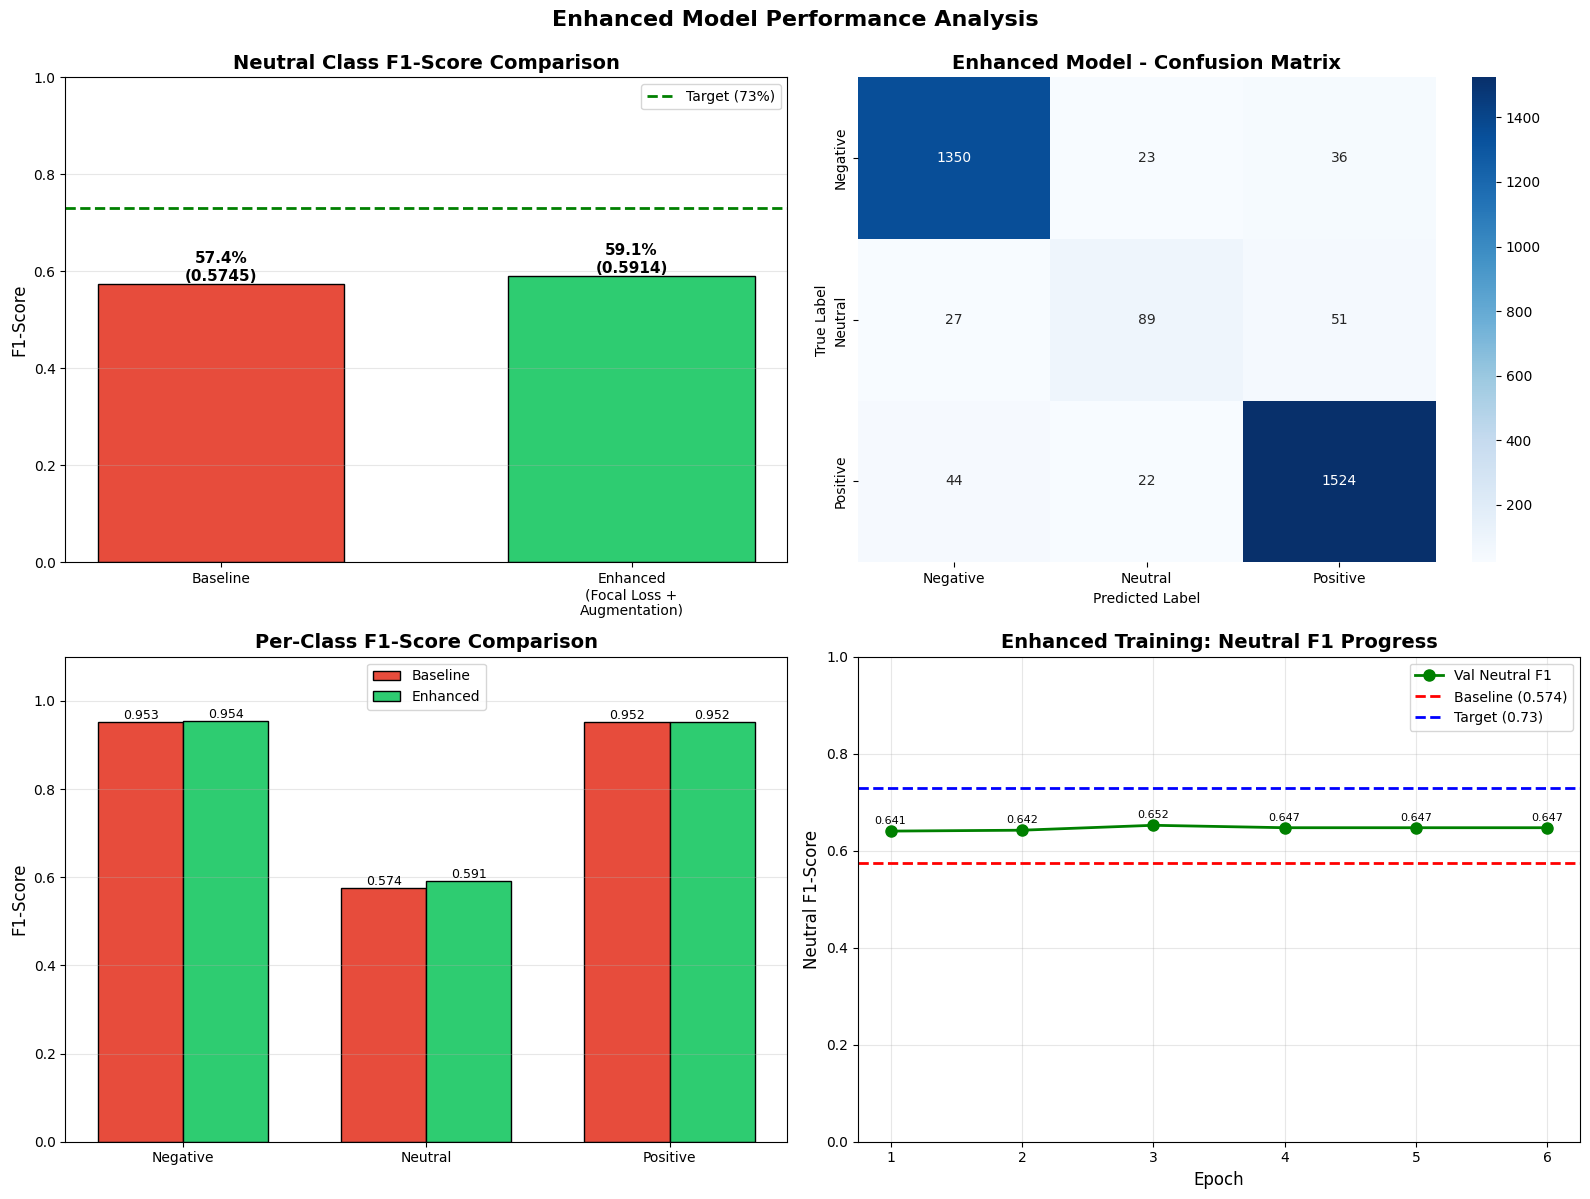


✅ Visualizations saved to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Baseline/enhanced_model_comparison.png


In [67]:
# Visualization 1: Comparison - Baseline vs Enhanced
print("="*80)
print("STEP 7: VISUALIZING RESULTS")
print("="*80)

# FIX: Explicitly redefine RESULTS_DIR to avoid /data/ in path
RESULTS_DIR = '/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Baseline'

# Ensure directory exists
print(f"\n📁 Results directory: {RESULTS_DIR}")
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"✅ Directory ensured")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Neutral F1-Score Comparison
models = ['Baseline', 'Enhanced\n(Focal Loss +\nAugmentation)']
neutral_f1_scores = [baseline_neutral_f1, enhanced_neutral_f1]
colors_comp = ['#e74c3c', '#2ecc71']

bars = axes[0, 0].bar(models, neutral_f1_scores, color=colors_comp, edgecolor='black', width=0.6)
axes[0, 0].set_ylabel('F1-Score', fontsize=12)
axes[0, 0].set_title('Neutral Class F1-Score Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].axhline(y=0.73, color='green', linestyle='--', linewidth=2, label='Target (73%)')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].legend()

for bar, score in zip(bars, neutral_f1_scores):
    height = bar.get_height()
    axes[0, 0].annotate(f'{score:.1%}\n({score:.4f})',
                       xy=(bar.get_x() + bar.get_width()/2, height),
                       ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Enhanced Model Confusion Matrix
cm_enh = confusion_matrix(test_labels_enh, test_preds_enh)
sns.heatmap(cm_enh, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'],
            ax=axes[0, 1])
axes[0, 1].set_title('Enhanced Model - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Predicted Label')
axes[0, 1].set_ylabel('True Label')

# 3. Per-Class F1 Comparison
labels_vis = ['Negative', 'Neutral', 'Positive']
baseline_f1s = [report[label]['f1-score'] for label in labels_vis]
enhanced_f1s = [test_report_enh[label]['f1-score'] for label in labels_vis]

x = np.arange(len(labels_vis))
width = 0.35

bars1 = axes[1, 0].bar(x - width/2, baseline_f1s, width, label='Baseline',
                       color='#e74c3c', edgecolor='black')
bars2 = axes[1, 0].bar(x + width/2, enhanced_f1s, width, label='Enhanced',
                       color='#2ecc71', edgecolor='black')

axes[1, 0].set_ylabel('F1-Score', fontsize=12)
axes[1, 0].set_title('Per-Class F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(labels_vis)
axes[1, 0].legend()
axes[1, 0].set_ylim(0, 1.1)
axes[1, 0].grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1, 0].annotate(f'{height:.3f}',
                           xy=(bar.get_x() + bar.get_width()/2, height),
                           ha='center', va='bottom', fontsize=9)

# 4. Training History - Neutral F1
epochs_range = range(1, len(history_enhanced['val_f1_neutral']) + 1)
axes[1, 1].plot(epochs_range, history_enhanced['val_f1_neutral'],
               'g-o', linewidth=2, markersize=8, label='Val Neutral F1')
axes[1, 1].axhline(y=baseline_neutral_f1, color='red', linestyle='--',
                  linewidth=2, label=f'Baseline ({baseline_neutral_f1:.3f})')
axes[1, 1].axhline(y=0.73, color='blue', linestyle='--',
                  linewidth=2, label='Target (0.73)')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Neutral F1-Score', fontsize=12)
axes[1, 1].set_title('Enhanced Training: Neutral F1 Progress', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(0, 1)

# Add value annotations
for i, val in enumerate(history_enhanced['val_f1_neutral']):
    axes[1, 1].annotate(f'{val:.3f}',
                       xy=(i+1, val),
                       textcoords="offset points",
                       xytext=(0, 5),
                       ha='center',
                       fontsize=8)

plt.suptitle('Enhanced Model Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()

# Save with explicit path
save_path = f'{RESULTS_DIR}/enhanced_model_comparison.png'
print(f"\n💾 Saving to: {save_path}")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"✅ File saved successfully!")
plt.show()

print("\n✅ Visualizations saved to:", save_path)

### 19.8. Step 8: Save Enhanced Model

In [68]:
# Save the enhanced model
print("="*80)
print("STEP 8: SAVING ENHANCED MODEL")
print("="*80)

MODEL_SAVE_PATH_ENHANCED = f'{RESULTS_DIR}/phobert_enhanced_focal_model.pt'

torch.save({
    'model_state_dict': best_model_state_enhanced,
    'optimizer_state_dict': optimizer_enhanced.state_dict(),
    'history': history_enhanced,
    'best_val_f1': best_val_f1_enhanced,
    'best_val_f1_neutral': best_val_f1_neutral,
    'test_metrics': {
        'accuracy': test_acc_enh,
        'f1_macro': test_f1_enh,
        'precision': test_precision_enh,
        'recall': test_recall_enh,
        'neutral_f1': enhanced_neutral_f1
    },
    'label_map': LABEL_MAP,
    'config': {
        'model_name': MODEL_NAME,
        'max_length': MAX_LENGTH,
        'batch_size': BATCH_SIZE_ENHANCED,
        'epochs': EPOCHS_ENHANCED,
        'learning_rate': LEARNING_RATE_ENHANCED,
        'warmup_steps': WARMUP_STEPS_ENHANCED,
        'focal_loss_gamma': 2.0,
        'focal_loss_alpha': alpha_focal.cpu().numpy().tolist(),
        'training_samples': len(train_dataset_enhanced),
        'augmentation': 'random_deletion_swap_insertion',
        'oversampling_ratio': 0.18
    }
}, MODEL_SAVE_PATH_ENHANCED)

print(f"\n✅ Enhanced model saved to:")
print(f"   {MODEL_SAVE_PATH_ENHANCED}")

# Save comparison summary
summary_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score (Macro)', 'Precision (Macro)', 'Recall (Macro)', 'Neutral F1'],
    'Baseline': [
        f"{test_acc:.4f}",
        f"{test_f1:.4f}",
        f"{test_precision:.4f}",
        f"{test_recall:.4f}",
        f"{baseline_neutral_f1:.4f}"
    ],
    'Enhanced': [
        f"{test_acc_enh:.4f}",
        f"{test_f1_enh:.4f}",
        f"{test_precision_enh:.4f}",
        f"{test_recall_enh:.4f}",
        f"{enhanced_neutral_f1:.4f}"
    ],
    'Improvement': [
        f"{test_acc_enh - test_acc:+.4f}",
        f"{test_f1_enh - test_f1:+.4f}",
        f"{test_precision_enh - test_precision:+.4f}",
        f"{test_recall_enh - test_recall:+.4f}",
        f"{enhanced_neutral_f1 - baseline_neutral_f1:+.4f}"
    ]
})

summary_comparison.to_csv(f'{RESULTS_DIR}/model_comparison_summary.csv', index=False)

print(f"\n✅ Comparison summary saved to:")
print(f"   {RESULTS_DIR}/model_comparison_summary.csv")

print("\n" + "="*80)
print("📊 FINAL SUMMARY")
print("="*80)
print(summary_comparison.to_string(index=False))
print("="*80)

STEP 8: SAVING ENHANCED MODEL

✅ Enhanced model saved to:
   /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Baseline/phobert_enhanced_focal_model.pt

✅ Comparison summary saved to:
   /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Baseline/model_comparison_summary.csv

📊 FINAL SUMMARY
           Metric Baseline Enhanced Improvement
         Accuracy   0.9356   0.9359     +0.0003
 F1-Score (Macro)   0.8264   0.8325     +0.0061
Precision (Macro)   0.8642   0.8534     -0.0108
   Recall (Macro)   0.8023   0.8165     +0.0142
       Neutral F1   0.5745   0.5914     +0.0169
